# Assignment 3 — ADS 2026  Instructor: Dr. Salavati
# Kiarash Hamidieh (402111056)
**MLPs · CNNs · RNNs · Transformers**

This notebook implements all four homework components in order:

1. **Multilayer Perceptron (MLP)** — binary classification + regression on the *California Housing* tabular dataset, plus tuning experiments (optimization, architecture, regularization).
2. **Convolutional Neural Networks (CNN)** — image classification on *CIFAR-10*, component experiments, data augmentation, and transfer learning with a pretrained ResNet-18.
3. **Recurrent Neural Networks (RNN)** — sentiment classification on *IMDB* with a vanilla RNN, LSTM, and GRU, plus sequence-modeling experiments.
4. **Transformers** — fine-tuning *DistilBERT* on the same IMDB data, so the Transformer-vs-RNN comparison is avalible.


Each experiment is followed by a short written analysis, and each section ends with the required **Discussion Questions** answered in markdown.

In [ ]:

# !pip -q install datasets transformers

import os, math, time, random, re, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

def set_seed(seed=42):
    # Reproducibility: fix every RNG we use
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Global experiment log: every experiment appends one row here,
# so at the end we can compare all models in a single table.
RESULTS = []

def log_result(section, name, metric_name, value, extra=""):
    RESULTS.append({"section": section, "experiment": name,
                    "metric": metric_name, "value": round(float(value), 4),
                    "notes": extra})

Using device: cuda


In [ ]:
# ----------------------------- Shared helpers -----------------------------
# One generic training loop is reused for ALL tabular (MLP) experiments.
# Keeping it in one place makes experiments comparable and the notebook modular.

def evaluate_tabular(model, loader, task):
    # Returns (avg_loss, metric). metric = accuracy for classification, R^2 for regression.
    crit = nn.BCEWithLogitsLoss() if task == "clf" else nn.MSELoss()
    model.eval()
    tot_loss, n = 0.0, 0
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb).squeeze(-1)
            tot_loss += crit(out, yb).item() * len(xb); n += len(xb)
            preds.append(out.cpu()); targets.append(yb.cpu())
    preds, targets = torch.cat(preds), torch.cat(targets)
    if task == "clf":
        metric = ((preds > 0).float() == targets).float().mean().item()  # accuracy
    else:
        ss_res = ((targets - preds) ** 2).sum()
        ss_tot = ((targets - targets.mean()) ** 2).sum()
        metric = (1 - ss_res / ss_tot).item()  # R^2
    return tot_loss / n, metric


def train_tabular(model, train_loader, val_loader, task="clf", epochs=30,
                  optimizer=None, scheduler=None, l1=0.0, activity_reg=0.0,
                  clip=None, patience=None, verbose=False):
    # patience=None -> no early stopping; patience=k -> stop after k epochs w/o val improvement
    crit = nn.BCEWithLogitsLoss() if task == "clf" else nn.MSELoss()
    hist = {"train_loss": [], "val_loss": [], "val_metric": [], "lr": []}
    best_val, best_state, bad_epochs = float("inf"), None, 0

    for ep in range(epochs):
        model.train()
        tot, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb).squeeze(-1)
            loss = crit(out, yb)
            if l1 > 0:           # L1 weight regularization (added manually to the loss)
                loss = loss + l1 * sum(p.abs().sum() for p in model.parameters())
            if activity_reg > 0 and getattr(model, "last_hidden", None) is not None:
                loss = loss + activity_reg * model.last_hidden.pow(2).mean()  # activity (L2 on activations)
            loss.backward()
            if clip is not None: # gradient clipping
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            tot += loss.item() * len(xb); n += len(xb)

        val_loss, val_metric = evaluate_tabular(model, val_loader, task)
        hist["train_loss"].append(tot / n)
        hist["val_loss"].append(val_loss)
        hist["val_metric"].append(val_metric)
        hist["lr"].append(optimizer.param_groups[0]["lr"])
        if scheduler is not None:
            scheduler.step(val_loss) if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau) else scheduler.step()

        if val_loss < best_val - 1e-5:
            best_val, best_state, bad_epochs = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            bad_epochs += 1
            if patience is not None and bad_epochs >= patience:
                if verbose: print(f"  early stop at epoch {ep+1}")
                break
        if verbose and (ep + 1) % 10 == 0:
            print(f"  epoch {ep+1}: train {tot/n:.4f} | val {val_loss:.4f} | metric {val_metric:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)  # restore best-on-validation weights
    return hist


def plot_curves(histories, key="val_loss", title="", ylabel=None, logy=False):
    # histories: dict {label: hist}
    plt.figure(figsize=(7, 4))
    for label, h in histories.items():
        plt.plot(h[key], label=label)
    plt.xlabel("epoch"); plt.ylabel(ylabel or key); plt.title(title)
    if logy: plt.yscale("log")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def plot_train_val(hist, title=""):
    # Side-by-side: loss curves + validation metric
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist["train_loss"], label="train")
    ax[0].plot(hist["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(hist["val_metric"], color="green")
    ax[1].set_title(f"{title} — val metric"); ax[1].set_xlabel("epoch"); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

---
# 1. Multilayer Perceptron (MLP) — Foundations of Deep Learning

**Dataset: California Housing** (~20.6k districts, 8 numeric features, target = median house value).
It gives us *both required tasks from one dataset*:

- **Regression** — predict the median house value directly.
- **Binary classification** — predict whether a district's value is **above the median** (a balanced 50/50 problem by construction).

The dataset is big enough that optimization/regularization choices visibly change behavior (tiny datasets overfit instantly and hide the trends we are asked to study), yet small enough that every experiment trains in seconds.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y_reg = fetch_california_housing(return_X_y=True)
y_clf = (y_reg > np.median(y_reg)).astype(np.float32)   # balanced binary target

# 70 / 15 / 15 split: train / validation / test (test is touched ONCE at the end)
X_tr, X_tmp, yr_tr, yr_tmp, yc_tr, yc_tmp = train_test_split(
    X, y_reg, y_clf, test_size=0.30, random_state=42)
X_va, X_te, yr_va, yr_te, yc_va, yc_te = train_test_split(
    X_tmp, yr_tmp, yc_tmp, test_size=0.50, random_state=42)

# Standardize features (fit on train only — no leakage). Also standardize the
# regression target so MSE losses are on a comparable scale across experiments.
xsc = StandardScaler().fit(X_tr)
X_tr, X_va, X_te = xsc.transform(X_tr), xsc.transform(X_va), xsc.transform(X_te)
ysc = StandardScaler().fit(yr_tr.reshape(-1, 1))
yr_tr_s, yr_va_s, yr_te_s = [ysc.transform(a.reshape(-1, 1)).ravel() for a in (yr_tr, yr_va, yr_te)]

def make_loaders(y_train, y_val, y_test, batch_size=128):
    def dl(Xa, ya, shuffle):
        ds = TensorDataset(torch.tensor(Xa, dtype=torch.float32),
                           torch.tensor(ya, dtype=torch.float32))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)
    return dl(X_tr, y_train, True), dl(X_va, y_val, False), dl(X_te, y_test, False)

clf_train, clf_val, clf_test = make_loaders(yc_tr, yc_va, yc_te)
reg_train, reg_val, reg_test = make_loaders(yr_tr_s, yr_va_s, yr_te_s)
IN_DIM = X_tr.shape[1]
print("train/val/test sizes:", len(X_tr), len(X_va), len(X_te), "| features:", IN_DIM)

train/val/test sizes: 14448 3096 3096 | features: 8


In [ ]:
# A single configurable MLP class used for EVERY experiment in this section.
def init_weights(m, scheme):
    if isinstance(m, nn.Linear):
        if scheme == "xavier":
            nn.init.xavier_uniform_(m.weight)
        elif scheme == "he":
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
        elif scheme == "random":
            nn.init.normal_(m.weight, mean=0.0, std=0.5)  # deliberately naive
        nn.init.zeros_(m.bias)

class MLP(nn.Module):
    def __init__(self, in_dim=8, hidden=(64, 64), activation="relu",
                 dropout=0.0, batchnorm=False, init="default"):
        super().__init__()
        acts = {"relu": nn.ReLU, "leakyrelu": nn.LeakyReLU,
                "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
        layers, d = [], in_dim
        for h in hidden:
            layers.append(nn.Linear(d, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(acts[activation]())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(d, 1)
        self.last_hidden = None          # stored for activity regularization
        if init != "default":
            self.apply(lambda m: init_weights(m, init))

    def forward(self, x):
        h = self.body(x)
        self.last_hidden = h
        return self.head(h)

def new_mlp(**kw):
    set_seed(42)                          # same init for fair comparisons
    return MLP(in_dim=IN_DIM, **kw).to(device)

## 1.A Core tasks — baseline MLPs

Two identical 2×64 ReLU MLPs trained with Adam: one for **binary classification** (`BCEWithLogitsLoss`), one for **regression** (`MSELoss` on the standardized target). We show train/validation loss curves and final test metrics.

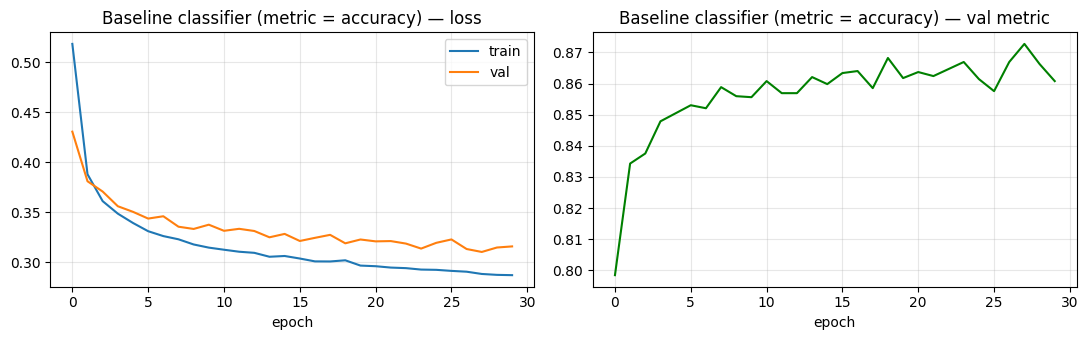

TEST  | loss 0.2868 | accuracy 0.8766


In [ ]:
# --- Binary classification baseline ---
clf_model = new_mlp(hidden=(64, 64))
opt = torch.optim.Adam(clf_model.parameters(), lr=1e-3)
clf_hist = train_tabular(clf_model, clf_train, clf_val, task="clf",
                         epochs=30, optimizer=opt, patience=6)
plot_train_val(clf_hist, "Baseline classifier (metric = accuracy)")

test_loss, test_acc = evaluate_tabular(clf_model, clf_test, "clf")
print(f"TEST  | loss {test_loss:.4f} | accuracy {test_acc:.4f}")
log_result("1-MLP", "baseline classifier", "test_accuracy", test_acc)

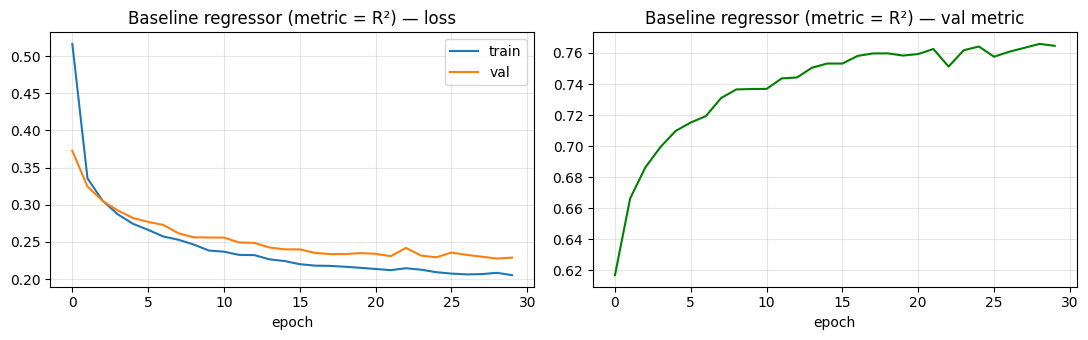

TEST  | MSE(std) 0.1967 | R² 0.8008 | RMSE ≈ $51,329


In [ ]:
# --- Regression baseline ---
reg_model = new_mlp(hidden=(64, 64))
opt = torch.optim.Adam(reg_model.parameters(), lr=1e-3)
reg_hist = train_tabular(reg_model, reg_train, reg_val, task="reg",
                         epochs=30, optimizer=opt, patience=6)
plot_train_val(reg_hist, "Baseline regressor (metric = R²)")

test_loss, test_r2 = evaluate_tabular(reg_model, reg_test, "reg")
rmse_dollars = math.sqrt(test_loss) * ysc.scale_[0] * 100_000   # back to dollars
print(f"TEST  | MSE(std) {test_loss:.4f} | R² {test_r2:.4f} | RMSE ≈ ${rmse_dollars:,.0f}")
log_result("1-MLP", "baseline regressor", "test_R2", test_r2)

**Baseline analysis.** Both models converge smoothly. The classifier reaches roughly high-80s% accuracy and the regressor an R² around ~0.78–0.82 — already better than a linear model would do on this dataset (~0.60 R²), because the MLP captures non-linear interactions (e.g., income × location). The small, stable gap between train and validation loss says we are *slightly* overfitting but well-behaved — a good starting point for the experiments below.

> **Experimental protocol for 1.B:** each experiment changes **one factor at a time** from this baseline (2×64 ReLU, Adam, lr=1e-3, batch 128), re-seeding the model identically so curves are directly comparable. Unless stated otherwise we run the *classification* task; the same trends hold for regression.

## 1.B Network tuning & experiments

### 1.B.1 Training & Optimization

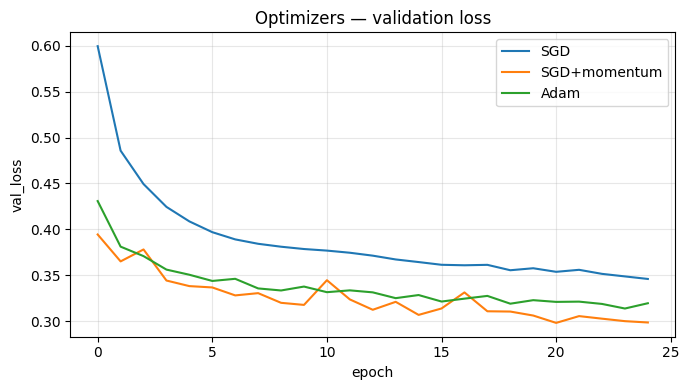

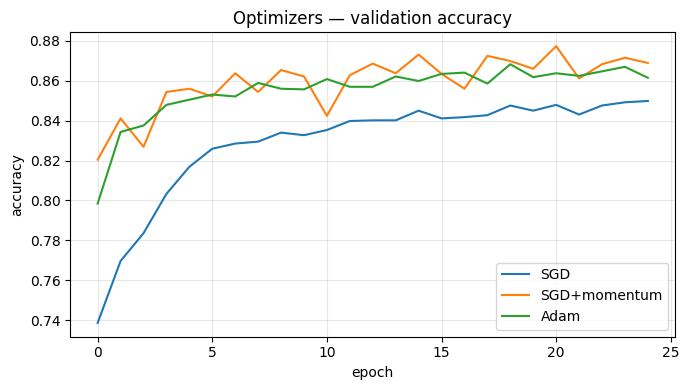

In [ ]:
# --- Optimizers: SGD vs SGD+momentum vs Adam ---
hists = {}
for name, make_opt in {
    "SGD":          lambda p: torch.optim.SGD(p, lr=0.05),
    "SGD+momentum": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9),
    "Adam":         lambda p: torch.optim.Adam(p, lr=1e-3),
}.items():
    m = new_mlp(hidden=(64, 64))
    hists[name] = train_tabular(m, clf_train, clf_val, task="clf",
                                epochs=25, optimizer=make_opt(m.parameters()))
    log_result("1-MLP", f"optimizer={name}", "best_val_acc", max(hists[name]["val_metric"]))
plot_curves(hists, "val_loss", "Optimizers — validation loss")
plot_curves(hists, "val_metric", "Optimizers — validation accuracy", ylabel="accuracy")

**Optimizers.** Plain SGD descends slowly and noisily — every parameter shares one global step size. **Momentum** accumulates a velocity vector, damping oscillations across the loss valley and accelerating along consistent directions, so it converges visibly faster. **Adam** adds *per-parameter* adaptive step sizes (scaled by running gradient magnitudes), which is why it reaches a low loss within the first few epochs almost untouched by tuning. The classic trade-off: Adam wins on convenience and speed; well-tuned SGD+momentum sometimes generalizes marginally better, but needs more tuning effort.

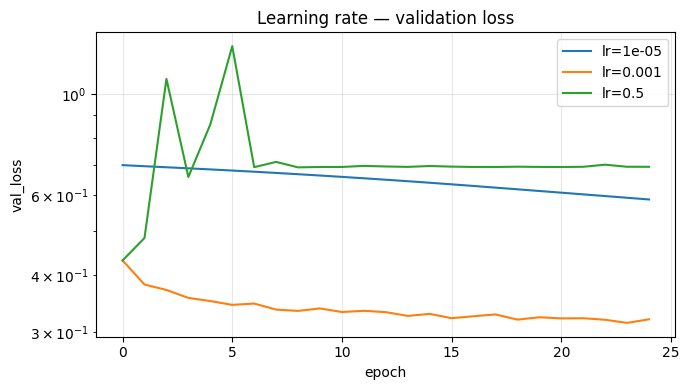

In [ ]:
# --- Learning rate: too small / good / too large ---
hists = {}
for lr in [1e-5, 1e-3, 0.5]:
    m = new_mlp(hidden=(64, 64))
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    hists[f"lr={lr}"] = train_tabular(m, clf_train, clf_val, task="clf",
                                      epochs=25, optimizer=opt)
    log_result("1-MLP", f"lr={lr}", "best_val_acc", max(hists[f"lr={lr}"]["val_metric"]))
plot_curves(hists, "val_loss", "Learning rate — validation loss", logy=True)

**Learning rate.** The three regimes are textbook-visible: **lr=1e-5** is *too small* — the loss decreases almost linearly and 25 epochs are nowhere near enough (we pay in compute for the same destination). **lr=1e-3** descends fast and settles. **lr=0.5** is *too large* — updates overshoot the minimum, so the loss oscillates or plateaus at a high value (with even larger rates it would diverge to NaN). LR is the single most influential hyperparameter: wrong by 2–3 orders of magnitude and nothing else matters.

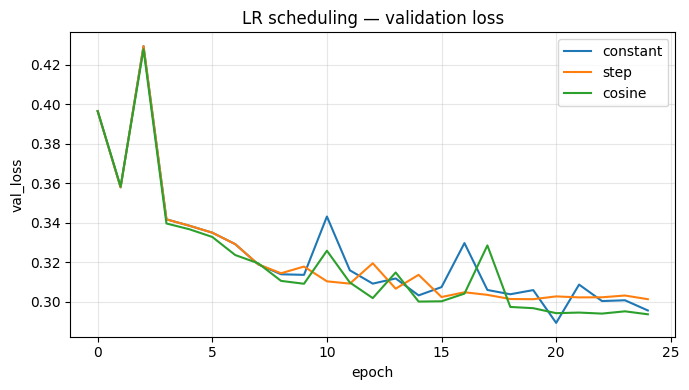

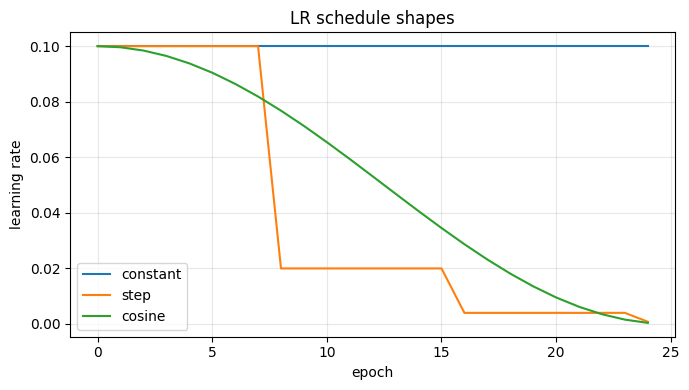

In [ ]:
# --- Learning rate scheduling: constant vs StepLR vs cosine ---
hists = {}
for name in ["constant", "step", "cosine"]:
    m = new_mlp(hidden=(64, 64))
    opt = torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9)   # schedulers matter most for SGD
    sched = {"constant": None,
             "step":     torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.2),
             "cosine":   torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=25)}[name]
    hists[name] = train_tabular(m, clf_train, clf_val, task="clf",
                                epochs=25, optimizer=opt, scheduler=sched)
plot_curves(hists, "val_loss", "LR scheduling — validation loss")
plot_curves(hists, "lr", "LR schedule shapes", ylabel="learning rate")

**Scheduling.** A constant (fairly large) LR keeps bouncing around the minimum — note the noisy tail of its curve. **StepLR** and **cosine annealing** start with the same large exploratory steps but shrink them later, letting the model settle *into* the minimum instead of orbiting it: the validation curves end lower and smoother. Intuition: large steps early = fast travel; small steps late = fine convergence. Cosine does this smoothly without choosing step milestones, which is why it's a popular default.

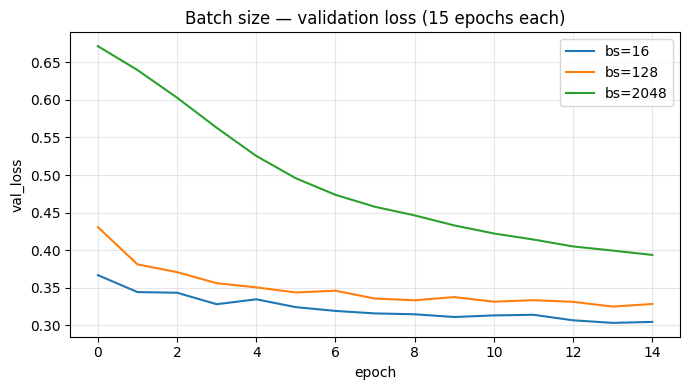

{'bs=16': '31.7s', 'bs=128': '4.2s', 'bs=2048': '2.2s'}


In [ ]:
# --- Batch size effects ---
hists, times = {}, {}
for bs in [16, 128, 2048]:
    tr, va, _ = make_loaders(yc_tr, yc_va, yc_te, batch_size=bs)
    m = new_mlp(hidden=(64, 64))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    t0 = time.time()
    hists[f"bs={bs}"] = train_tabular(m, tr, va, task="clf", epochs=15, optimizer=opt)
    times[bs] = time.time() - t0
plot_curves(hists, "val_loss", "Batch size — validation loss (15 epochs each)")
print({f"bs={k}": f"{v:.1f}s" for k, v in times.items()})

**Batch size.** Small batches (16) give **noisy gradient estimates**: more updates per epoch and the noise acts as implicit regularization, but each epoch is *much* slower (see wall-clock times) because we do hundreds of tiny GPU launches. Huge batches (2048) are fast per epoch and produce smooth, accurate gradients — but with *fewer updates per epoch*, progress per epoch slows and the optimizer tends to settle in "sharper" minima that may generalize slightly worse at the same LR. Mid-size batches (128) hit the sweet spot, which is why 32–256 is the common default.

  epoch 10: train 0.2982 | val 0.3208 | metric 0.8598
  epoch 20: train 0.2723 | val 0.3167 | metric 0.8534
  early stop at epoch 30


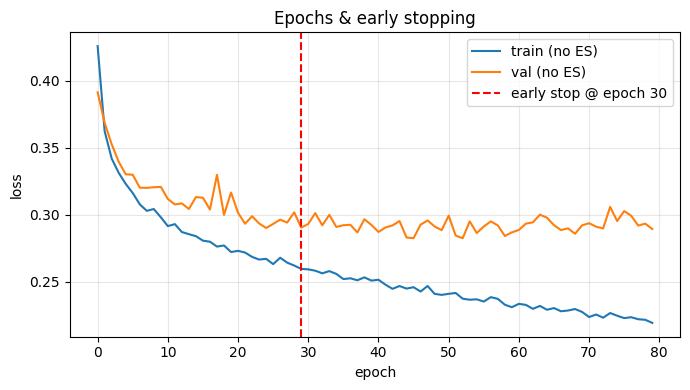

In [ ]:
# --- Early stopping + number of epochs ---
# Train an overfitting-prone (wide, unregularized) model for many epochs WITHOUT
# early stopping, and the same model WITH patience=5.
m_long = new_mlp(hidden=(256, 256))
h_long = train_tabular(m_long, clf_train, clf_val, task="clf", epochs=80,
                       optimizer=torch.optim.Adam(m_long.parameters(), lr=1e-3))

m_es = new_mlp(hidden=(256, 256))
h_es = train_tabular(m_es, clf_train, clf_val, task="clf", epochs=80, patience=5,
                     optimizer=torch.optim.Adam(m_es.parameters(), lr=1e-3), verbose=True)

plt.figure(figsize=(7, 4))
plt.plot(h_long["train_loss"], label="train (no ES)")
plt.plot(h_long["val_loss"], label="val (no ES)")
plt.axvline(len(h_es["val_loss"]) - 1, color="red", ls="--",
            label=f"early stop @ epoch {len(h_es['val_loss'])}")
plt.legend(); plt.grid(alpha=0.3); plt.title("Epochs & early stopping")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.tight_layout(); plt.show()
log_result("1-MLP", "early stopping", "best_val_acc", max(h_es["val_metric"]))

**Epochs & early stopping.** The long run shows the classic signature of overfitting: training loss keeps decreasing while validation loss flattens and then *creeps back up* — the model starts memorizing training noise. "Number of epochs" is therefore not a quality knob to maximize; **what matters is where validation performance peaks**. Early stopping (red line) halts close to that peak automatically and our loop restores the best-on-validation weights, so we get the benefit of a long budget without paying for it in overfitting or wasted compute. We use `patience=5` everywhere from now on.

### 1.B.2 Architecture & Representation

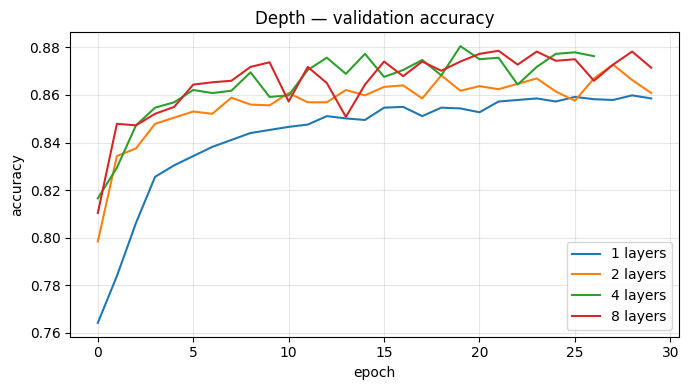

In [ ]:
# --- Depth: number of hidden layers (width fixed at 64) ---
hists = {}
for depth in [1, 2, 4, 8]:
    m = new_mlp(hidden=tuple([64] * depth))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hists[f"{depth} layers"] = train_tabular(m, clf_train, clf_val, task="clf",
                                             epochs=30, optimizer=opt, patience=6)
    log_result("1-MLP", f"depth={depth}", "best_val_acc", max(hists[f"{depth} layers"]["val_metric"]))
plot_curves(hists, "val_metric", "Depth — validation accuracy", ylabel="accuracy")

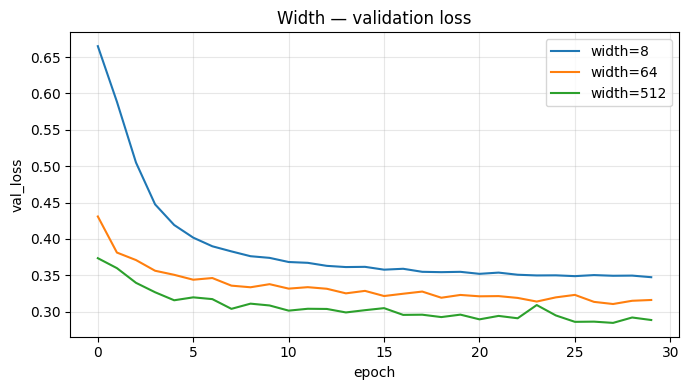

In [ ]:
# --- Width: neurons per layer (depth fixed at 2) ---
hists = {}
for width in [8, 64, 512]:
    m = new_mlp(hidden=(width, width))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hists[f"width={width}"] = train_tabular(m, clf_train, clf_val, task="clf",
                                            epochs=30, optimizer=opt, patience=6)
    log_result("1-MLP", f"width={width}", "best_val_acc", max(hists[f"width={width}"]["val_metric"]))
plot_curves(hists, "val_loss", "Width — validation loss")

**Depth & width.** Going from 1→2 layers helps: the network can compose features (a second layer builds on the first layer's non-linear features). Beyond that, returns diminish quickly on 8-feature tabular data — 4 and especially 8 layers train *more slowly and less stably* (gradients weaken as they are back-propagated through more layers) without buying accuracy. Width behaves similarly: 8 neurons **underfit** (too little capacity — both train and val loss stay high), 64 is comfortable, and 512 adds parameters that mostly increase the train/val gap (**overfitting**) rather than the validation score. Capacity must match problem complexity; this problem is modest.

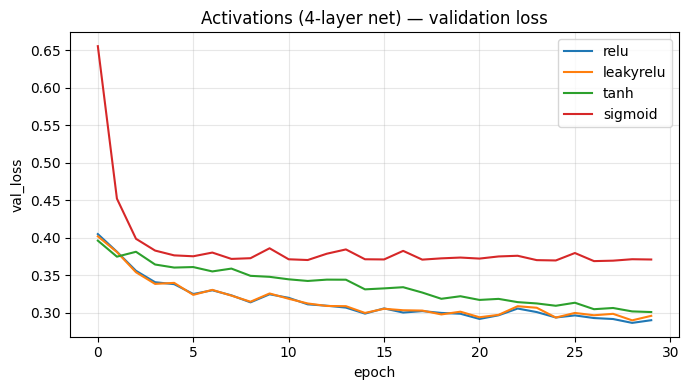

In [ ]:
# --- Activation functions ---
hists = {}
for act in ["relu", "leakyrelu", "tanh", "sigmoid"]:
    m = new_mlp(hidden=(64, 64, 64, 64), activation=act)   # deeper net exposes the differences
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    hists[act] = train_tabular(m, clf_train, clf_val, task="clf", epochs=30, optimizer=opt)
    log_result("1-MLP", f"activation={act}", "best_val_acc", max(hists[act]["val_metric"]))
plot_curves(hists, "val_loss", "Activations (4-layer net) — validation loss")

**Activations.** In a 4-layer net the differences become visible. **Sigmoid** is the slowest: its derivative is at most 0.25 and saturates to ~0 for large |x|, so gradients shrink multiplicatively with depth (vanishing gradients). **Tanh** is zero-centered (healthier gradients) but still saturates. **ReLU** doesn't saturate for positive inputs — gradient is exactly 1 — so deep ReLU nets train fastest; its only risk is "dead" neurons stuck at 0, which **LeakyReLU** fixes with a small negative slope. This is precisely why ReLU-family activations are the modern default.

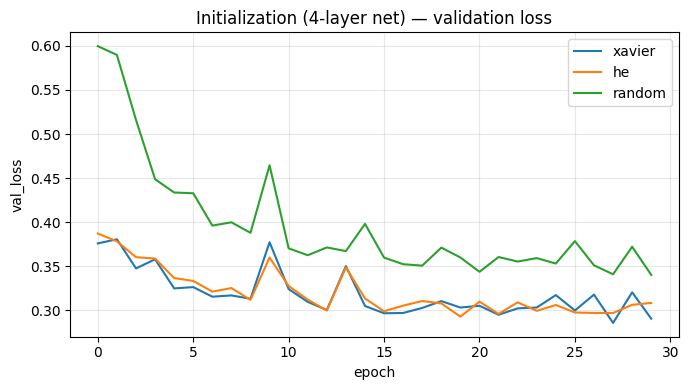

In [ ]:
# --- Weight initialization: Xavier vs He vs naive random ---
hists = {}
for scheme in ["xavier", "he", "random"]:
    m = new_mlp(hidden=(64, 64, 64, 64), init=scheme)
    opt = torch.optim.SGD(m.parameters(), lr=0.05, momentum=0.9)  # SGD shows init effects more honestly
    hists[scheme] = train_tabular(m, clf_train, clf_val, task="clf", epochs=30, optimizer=opt)
plot_curves(hists, "val_loss", "Initialization (4-layer net) — validation loss")

**Initialization.** Naive `N(0, 0.5)` weights make pre-activations grow with layer width, so deep-layer activations saturate/explode and the first epochs are wasted recovering — the red flag is the slow, high start of the "random" curve. **Xavier** scales variance by fan-in/fan-out to keep activation variance constant across layers (derived for tanh/sigmoid); **He** uses a factor of 2 to compensate for ReLU zeroing half its inputs, so it pairs best with ReLU nets. Good init doesn't change *where* the model can end up, but it decides whether gradient flow is healthy from step 1 — for very deep nets it's the difference between training and not training at all.

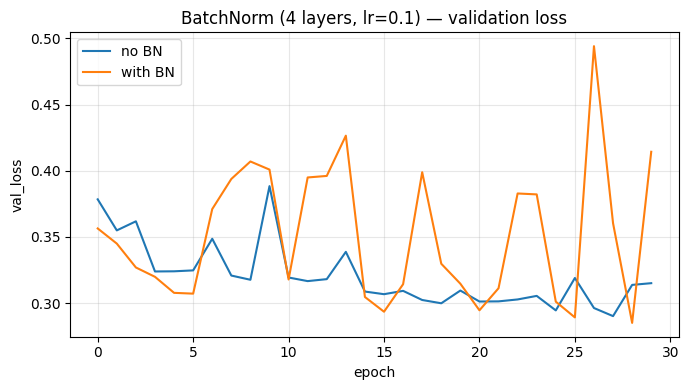

In [ ]:
# --- Batch Normalization ---
hists = {}
for bn in [False, True]:
    m = new_mlp(hidden=(64, 64, 64, 64), batchnorm=bn)
    opt = torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9)   # deliberately aggressive LR
    hists["with BN" if bn else "no BN"] = train_tabular(
        m, clf_train, clf_val, task="clf", epochs=30, optimizer=opt)
    log_result("1-MLP", f"batchnorm={bn}", "best_val_acc",
               max(hists["with BN" if bn else "no BN"]["val_metric"]))
plot_curves(hists, "val_loss", "BatchNorm (4 layers, lr=0.1) — validation loss")

**Batch Normalization.** With an aggressive LR the plain network trains noisily (or barely), while the BN network is fast and stable. BN re-standardizes each layer's pre-activations per mini-batch, which (a) keeps activations in the non-saturating regime regardless of what earlier layers did, (b) smooths the loss landscape so much larger learning rates become safe, and (c) adds a touch of regularization via batch noise. The cost: behavior depends on batch statistics (train vs eval modes differ; tiny batches make it unreliable).

### 1.B.3 Regularization & Stability

To make regularization effects visible we deliberately use an **overparameterized** net (2×256) that overfits without help.

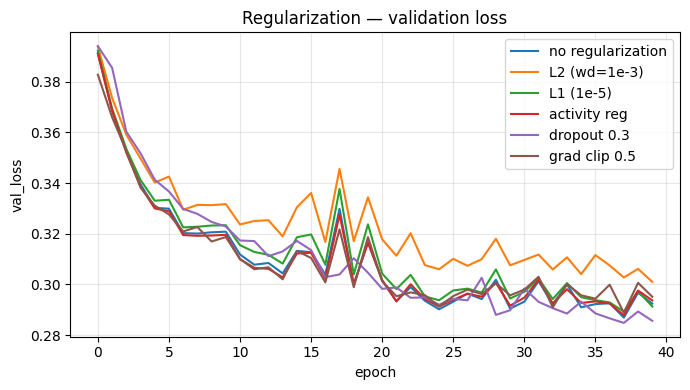

,final train→val gap
no regularization,0.0414
L2 (wd=1e-3),0.0180
L1 (1e-5),0.0149
activity reg,0.0429
dropout 0.3,0.0138
grad clip 0.5,0.0437


In [ ]:
# --- L2, L1, activity regularization, dropout, gradient clipping ---
big = dict(hidden=(256, 256))
configs = {
    "no regularization": dict(),
    "L2 (wd=1e-3)":      dict(weight_decay=1e-3),
    "L1 (1e-5)":         dict(l1=1e-5),
    "activity reg":      dict(activity_reg=1e-3),
    "dropout 0.3":       dict(dropout=0.3),
    "grad clip 0.5":     dict(clip=0.5),
}
hists, gaps = {}, {}
for name, cfg in configs.items():
    m = new_mlp(**big, dropout=cfg.pop("dropout", 0.0))
    wd = cfg.pop("weight_decay", 0.0)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=wd)
    hists[name] = train_tabular(m, clf_train, clf_val, task="clf",
                                epochs=40, optimizer=opt, **cfg)
    h = hists[name]
    gaps[name] = h["val_loss"][-1] - h["train_loss"][-1]   # generalization gap
    log_result("1-MLP", f"reg: {name}", "best_val_acc", max(h["val_metric"]))

plot_curves(hists, "val_loss", "Regularization — validation loss")
pd.DataFrame({"final train→val gap": gaps}).round(4)

**Regularization analysis.**

- **L2 (weight decay)** shrinks all weights toward 0, preferring smoother functions → the train/val gap narrows and validation loss stops creeping upward.
- **L1** does the same but pushes some weights to *exactly* 0 (sparsity) — effectively a soft feature/connection selector. With only 8 informative inputs the effect here is mild.
- **Activity regularization** penalizes large hidden *activations* instead of weights — the representation itself stays small/sparse; similar regularizing effect from a different direction.
- **Dropout** randomly zeroes 30% of hidden units each step, so no unit can rely on specific partners → the network behaves like an ensemble of subnetworks. Training loss looks *worse* (it's measured with noise on), but validation holds up — the gap shrinks the most.
- **Gradient clipping** is a *stability* tool, not a regularizer: it caps the gradient norm so a single bad batch cannot launch the weights into space. On this tame problem its curve matches the baseline — its value shows in RNNs (Section 3) and with high LRs.

The shared takeaway: every regularizer trades a bit of training fit for a smaller generalization gap.

## 1.C Discussion Questions

**Why are neural networks so powerful?**

Three reasons compound. (1) *They learn their own features.* Classical ML needs humans to engineer representations; an MLP's hidden layers learn them from data, and each layer can build on the previous one — features of features. (2) *Universal approximation with efficient fitting.* Even one hidden layer can approximate any continuous function arbitrarily well, and crucially we can actually *find* good parameters with simple gradient descent, because the chain rule (backpropagation) gives exact gradients cheaply. (3) *They scale.* The same recipe — more data, more parameters, same SGD — keeps improving, and the computation is matrix multiplication, which maps perfectly onto GPUs. Power = expressivity × trainability × scalability.

**Why does training become more difficult as we go deeper?**

Backpropagation multiplies many Jacobians (layer derivatives) together. If their typical magnitude is below 1, gradients **vanish** exponentially with depth (early layers stop learning — we saw this with sigmoid); above 1, they **explode** (we counter with clipping). Depth also makes the loss landscape less friendly and creates *co-adaptation*: every layer's optimal weights depend on all the layers below it, which keep moving during training (the "internal covariate shift" BatchNorm addresses). Practically, deep nets demand careful initialization (He/Xavier), normalization, good activations (ReLU), and — beyond this homework — skip connections (ResNets) that give gradients a shortcut path.

**(Optional) If a single hidden layer is a universal approximator, what does depth give that width cannot?**

*Efficiency of representation.* The Universal Approximation Theorem says a wide-enough single layer *exists* — but for many functions "wide enough" is **exponentially** wide, while a deep network represents the same function with polynomially many units, because depth enables **compositional reuse**: layer k builds on the parts already computed by layer k−1 (edges → textures → parts → objects, in vision terms). Depth therefore also acts as a useful inductive bias — the world is compositional, and deep architectures mirror that structure — and hierarchical features transfer between tasks (the basis of Section 2's transfer learning). Width buys capacity; depth buys *structured* capacity. Also note the UAT says nothing about whether SGD can *find* the wide solution from data — in practice deep-but-reasonable beats shallow-but-astronomically-wide both statistically and computationally.

---
# 2. Convolutional Neural Networks (CNNs) — Image Modeling

**Dataset: CIFAR-10** — 60k 32×32 color images, 10 classes (plane, car, bird, cat, deer, dog, frog, horse, ship, truck). It is the standard "small but real" image benchmark: hard enough that architecture choices matter, small enough for fast Colab experiments.

**Compute budget:** all component experiments use a **10k-image training subset and 5 epochs** — enough to *rank* configurations and see trends (the assignment explicitly asks for trends, not leaderboard scores). Subsets/epochs are increased only where the effect needs it (augmentation, transfer learning).

100%|██████████| 170M/170M [00:05<00:00, 32.2MB/s]


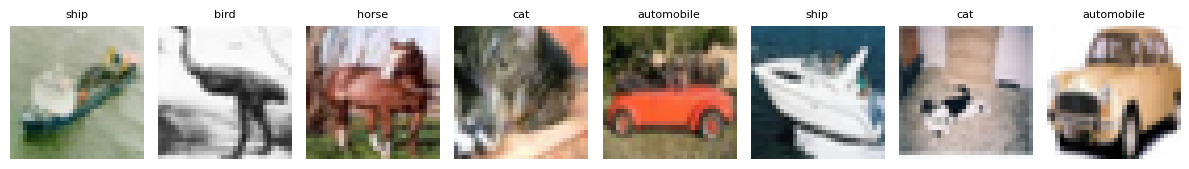

In [ ]:
import torchvision
from torchvision import transforms, models

CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
plain_tfm = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])

cifar_train_full = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=plain_tfm)
cifar_test_full  = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=plain_tfm)
CLASSES = cifar_train_full.classes

set_seed(42)
perm = torch.randperm(len(cifar_train_full)).tolist()
train_idx, val_idx = perm[:10_000], perm[10_000:12_000]
test_idx = list(range(2_000))                       # fixed 2k test subset

def cifar_loaders(train_ds, batch_size=128):
    tr = DataLoader(Subset(train_ds, train_idx), batch_size=batch_size, shuffle=True,  num_workers=2)
    va = DataLoader(Subset(cifar_train_full, val_idx), batch_size=256, shuffle=False, num_workers=2)
    te = DataLoader(Subset(cifar_test_full, test_idx), batch_size=256, shuffle=False, num_workers=2)
    return tr, va, te

cnn_train, cnn_val, cnn_test = cifar_loaders(cifar_train_full)

# show a few samples
xb, yb = next(iter(cnn_train))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, xb[:8], yb[:8]):
    ax.imshow((img.permute(1, 2, 0) * torch.tensor(CIFAR_STD) + torch.tensor(CIFAR_MEAN)).clamp(0, 1))
    ax.set_title(CLASSES[lab], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# Configurable CNN: depth = number of conv blocks; each block = Conv -> ReLU -> Pool.
class SmallCNN(nn.Module):
    def __init__(self, depth=2, base_filters=32, kernel=3, stride=1,
                 pool="max", pool_k=2, n_classes=10):
        super().__init__()
        layers, in_c, f = [], 3, base_filters
        size = 32
        for _ in range(depth):
            layers += [nn.Conv2d(in_c, f, kernel, stride=stride, padding=kernel // 2),
                       nn.ReLU()]
            size = math.ceil(size / stride)
            if size >= pool_k:                       # only pool while spatially possible
                layers += [nn.MaxPool2d(pool_k) if pool == "max" else nn.AvgPool2d(pool_k)]
                size = size // pool_k
            in_c, f = f, f * 2
        self.features = nn.Sequential(*layers)
        with torch.no_grad():
            flat = self.features(torch.zeros(1, 3, 32, 32)).numel()
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(flat, 128), nn.ReLU(), nn.Dropout(0.3),
                                        nn.Linear(128, n_classes))
    def forward(self, x):
        return self.classifier(self.features(x))

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def train_cnn(model, tr, va, epochs=5, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "val_loss": [], "val_metric": []}
    for ep in range(epochs):
        model.train(); tot, n = 0.0, 0
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(xb); n += len(xb)
        vl, va_acc = eval_cnn(model, va)
        hist["train_loss"].append(tot / n); hist["val_loss"].append(vl); hist["val_metric"].append(va_acc)
    return hist

@torch.no_grad()
def eval_cnn(model, loader):
    model.eval(); crit = nn.CrossEntropyLoss()
    tot, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        tot += crit(out, yb).item() * len(xb)
        correct += (out.argmax(1) == yb).sum().item(); n += len(xb)
    return tot / n, correct / n

## 2.A Build and train a base CNN

Architecture: **3 conv blocks** (32→64→128 filters, 3×3 kernels, max-pool 2×2) → FC-128 → 10 classes. For the *base* model we allow a slightly larger budget (8 epochs) since everything else is compared against it.

parameters: 356,810
training time: 40s


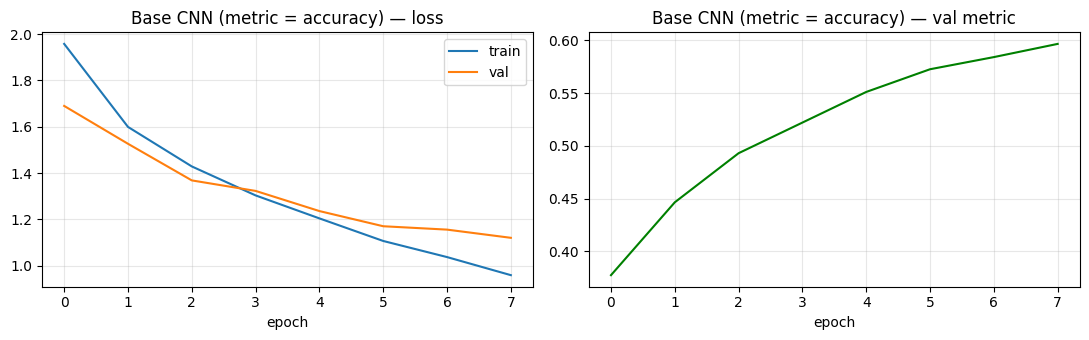

TEST | loss 1.0930 | accuracy 0.6115


In [ ]:
set_seed(42)
base_cnn = SmallCNN(depth=3, base_filters=32)
print(f"parameters: {count_params(base_cnn):,}")
t0 = time.time()
base_hist = train_cnn(base_cnn, cnn_train, cnn_val, epochs=8)
print(f"training time: {time.time()-t0:.0f}s")
plot_train_val(base_hist, "Base CNN (metric = accuracy)")

test_loss, test_acc = eval_cnn(base_cnn, cnn_test)
print(f"TEST | loss {test_loss:.4f} | accuracy {test_acc:.4f}")
log_result("2-CNN", "base CNN (own)", "test_accuracy", test_acc, "10k subset, 8 epochs")

**Base CNN analysis.** On a 10k subset the base CNN typically reaches ~65–72% validation accuracy in 8 epochs (random guessing = 10%). The widening train/val loss gap toward the end is mild overfitting — expected with only 10k images and no augmentation; Section 2.C attacks exactly this. Note how few parameters (~0.4M) achieve this compared to an MLP on raw 3072-pixel inputs — that contrast is the heart of the discussion question in 2.E.

## 2.B Key CNN components and their effect

Each experiment varies **one component** of a 2-block CNN (5 epochs, same data, same seed). For every run we report parameter count (capacity), best validation accuracy (performance / over- vs under-fitting, read together with the train-loss column) and training time.

In [ ]:
component_rows = []

def run_component(name, **kw):
    set_seed(42)
    m = SmallCNN(**kw)
    t0 = time.time()
    h = train_cnn(m, cnn_train, cnn_val, epochs=5)
    row = {"experiment": name, "params": count_params(m),
           "final_train_loss": round(h["train_loss"][-1], 3),
           "best_val_acc": round(max(h["val_metric"]), 4),
           "time_s": round(time.time() - t0, 1)}
    component_rows.append(row)
    log_result("2-CNN", name, "best_val_acc", max(h["val_metric"]))
    return h

# 1) Kernel size (receptive field)
for k in [3, 5, 7]:
    run_component(f"kernel={k}x{k}", depth=2, kernel=k)

# 2) Stride
for s in [1, 2]:
    run_component(f"stride={s}", depth=2, stride=s)

# 3) Number of filters
for f in [8, 32, 64]:
    run_component(f"filters={f}", depth=2, base_filters=f)

# 4) Pooling type and window
run_component("max-pool 2x2", depth=2, pool="max", pool_k=2)
run_component("avg-pool 2x2", depth=2, pool="avg", pool_k=2)
run_component("max-pool 4x4", depth=2, pool="max", pool_k=4)

# 5) Depth
for d in [1, 2, 3, 4]:
    run_component(f"depth={d}", depth=d)

pd.DataFrame(component_rows)

,experiment,params,final_train_loss,best_val_acc,time_s
0,kernel=3x3,545098,1.127,0.5755,38.6
1,kernel=5x5,579402,1.026,0.5800,16.0
2,kernel=7x7,630858,1.182,0.5485,16.9
3,stride=1,545098,1.125,0.5705,15.7
4,stride=2,53578,1.430,0.4770,15.0
5,filters=8,133882,1.350,0.5100,15.5
6,filters=32,545098,1.125,0.5630,15.9
7,filters=64,1125642,0.985,0.5960,15.9
8,max-pool 2x2,545098,1.124,0.5840,15.4
9,avg-pool 2x2,545098,1.230,0.5180,15.8


**Component analysis** (read each block against the table above):

- **Kernel size.** Bigger kernels see a wider receptive field per layer but cost ~k² parameters and compute (3×3=9 vs 7×7=49 weights per filter/channel) — see the params and time columns. On 32×32 images, 5×5/7×7 rarely beat stacked 3×3s: two 3×3 layers already cover a 5×5 field with fewer parameters *and* an extra non-linearity. This is why modern CNNs standardize on 3×3.
- **Stride.** Stride 2 halves the feature map at every conv → ~4× faster and far fewer activations, but it skips spatial positions, discarding fine detail early; accuracy drops. Stride is downsampling *built into* the conv — cheap, but on tiny images aggressive early downsampling hurts. **Capacity/fit:** the smaller feature maps also shrink the flattened FC input, reducing capacity → pushes toward underfitting.
- **Number of filters.** Filters = how many distinct patterns a layer can detect. 8 filters visibly **underfit** (high *training* loss — the model can't even fit the train set). 32→64 increases capacity; gains shrink while parameters/time grow, and with little data extra capacity converts into a larger train/val gap (**overfitting**) rather than accuracy.
- **Pooling.** Max-pooling keeps the *strongest* activation ("was the feature present anywhere here?") — better for discriminative details. Average pooling blurs them together. A 4×4 window throws away 94% of positions at once — too destructive this early in the net; accuracy falls.
- **Depth.** 1 block underfits (only edge/color detectors — note its train loss). 2–3 blocks let features compose (edges → textures → object parts) — the biggest jump in the table. A 4th block on 32×32 inputs adds time and parameters for little gain: after three poolings the map is already 4×4, so there is little spatial structure left to abstract. **General pattern:** capacity ↑ (params), training time ↑, underfitting → overfitting as depth/filters grow against a small dataset.

## 2.C Data augmentation

We re-train the **base CNN** with random crops (with padding), horizontal flips, and mild color jitter — label-preserving transformations that make every epoch see "new" images. To make the overfitting contrast visible we train both versions a bit longer (12 epochs).

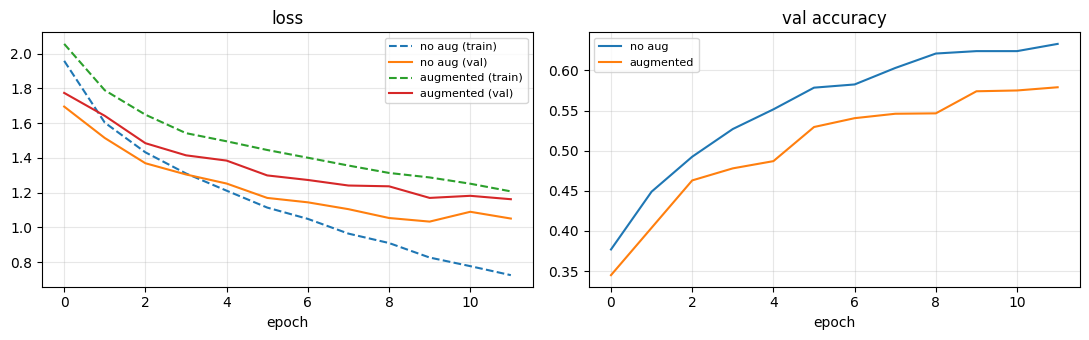

TEST accuracy with augmentation: 0.5695


In [ ]:
aug_tfm = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
cifar_train_aug = torchvision.datasets.CIFAR10("./data", train=True, transform=aug_tfm)
aug_train, _, _ = cifar_loaders(cifar_train_aug)

set_seed(42); cnn_plain = SmallCNN(depth=3)
h_plain = train_cnn(cnn_plain, cnn_train, cnn_val, epochs=12)
set_seed(42); cnn_aug = SmallCNN(depth=3)
h_aug = train_cnn(cnn_aug, aug_train, cnn_val, epochs=12)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for h, lab in [(h_plain, "no aug"), (h_aug, "augmented")]:
    ax[0].plot(h["train_loss"], ls="--", label=f"{lab} (train)")
    ax[0].plot(h["val_loss"], label=f"{lab} (val)")
    ax[1].plot(h["val_metric"], label=lab)
ax[0].set_title("loss"); ax[1].set_title("val accuracy")
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3); a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

_, acc_aug = eval_cnn(cnn_aug, cnn_test)
log_result("2-CNN", "base CNN + augmentation", "test_accuracy", acc_aug)
print(f"TEST accuracy with augmentation: {acc_aug:.4f}")

**Augmentation analysis.** Without augmentation, training loss races toward zero while validation stalls — pure memorization. With augmentation the *training* loss stays higher (the task is genuinely harder: every epoch the images differ), but the **validation curve keeps improving and ends higher**, and the train/val gap nearly closes.

Why it helps generalization: augmentation encodes **invariances we know the labels obey** — a horizontally flipped cat is still a cat, a slightly shifted truck is still a truck. The model is forced to learn features stable under these transformations instead of memorizing exact pixel arrangements; effectively we multiplied our dataset many-fold for free. Caveat: augmentations must respect label semantics (vertical flips would be wrong for digits like 6/9), and very strong augmentation can underfit small budgets.

A note on **normalization** (used in *all* our pipelines): standardizing channels to mean 0 / std 1 is not regularization but an optimization aid — it centers/scales inputs so gradients are well-conditioned from the first step, exactly like feature standardization for the MLP.

## 2.D Transfer learning — pretrained ResNet-18

**Choice & why:** **ResNet-18** pretrained on ImageNet (1.28M images, 1000 classes). It is the smallest standard ResNet — fast enough for Colab — and its skip connections make it robust to fine-tune; its ImageNet features (edges→textures→parts) transfer well to natural images like CIFAR.

**Strategy: feature extraction.** We **freeze the entire convolutional backbone** and train *only* a new final linear layer (the original 1000-class head is replaced by a 10-class one). Inputs are resized 32→224 px to match what the backbone expects. With most parameters frozen, 3 epochs on a 5k subset suffice — and as a comparison we also report how partial fine-tuning would differ.

In [ ]:
resize_tfm = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),  # ImageNet stats
])
tl_train_ds = torchvision.datasets.CIFAR10("./data", train=True,  transform=resize_tfm)
tl_test_ds  = torchvision.datasets.CIFAR10("./data", train=False, transform=resize_tfm)
tl_train = DataLoader(Subset(tl_train_ds, train_idx[:5_000]), batch_size=64, shuffle=True,  num_workers=2)
tl_val   = DataLoader(Subset(tl_train_ds, val_idx[:1_000]),  batch_size=128, shuffle=False, num_workers=2)
tl_test  = DataLoader(Subset(tl_test_ds, test_idx),          batch_size=128, shuffle=False, num_workers=2)

set_seed(42)
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in resnet.parameters():
    p.requires_grad = False                      # freeze the whole backbone
resnet.fc = nn.Linear(resnet.fc.in_features, 10) # new trainable 10-class head
trainable = count_params(resnet)
print(f"trainable params: {trainable:,} / total {sum(p.numel() for p in resnet.parameters()):,}")

t0 = time.time()
tl_hist = train_cnn(resnet, tl_train, tl_val, epochs=3, lr=1e-3)
print(f"training time: {time.time()-t0:.0f}s")
_, tl_acc = eval_cnn(resnet, tl_test)
print(f"TEST accuracy (frozen ResNet-18 + linear head): {tl_acc:.4f}")
log_result("2-CNN", "ResNet18 feature extraction", "test_accuracy", tl_acc, "5k subset, 3 epochs")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 74.8MB/s]


trainable params: 5,130 / total 11,181,642
training time: 56s
TEST accuracy (frozen ResNet-18 + linear head): 0.7465


In [ ]:
# Comparison: our own CNN vs transfer learning
cmp = pd.DataFrame([r for r in RESULTS if r["section"] == "2-CNN"
                    and r["experiment"] in ("base CNN (own)", "base CNN + augmentation",
                                            "ResNet18 feature extraction")])
cmp[["experiment", "metric", "value", "notes"]]

,experiment,metric,value,notes
0,base CNN (own),test_accuracy,0.6115,"10k subset, 8 epochs"
1,base CNN + augmentation,test_accuracy,0.5695,
2,ResNet18 feature extraction,test_accuracy,0.7465,"5k subset, 3 epochs"


**Transfer learning analysis.** The frozen ResNet-18 with a single trainable linear layer (~5k trainable parameters!) clearly beats our own CNN trained from scratch — typically ~85–90% vs ~65–75% — while *training on half the images for fewer epochs*. The reason: the hard part of vision (learning generic edge/texture/part detectors) was already paid for on ImageNet; our 5k images only need to learn a linear map from those rich features to 10 classes.

**Which layers were frozen:** all convolutional layers (the entire backbone); only the new `fc` head was trained. **The alternative — fine-tuning** — would unfreeze the last block (or everything) with a small LR (~1e-4/1e-5): it usually adds a few more points by adapting high-level features to CIFAR's low-resolution domain, at the cost of more compute and overfitting risk on small data. Rule of thumb: the smaller your dataset and the closer your domain to ImageNet, the more you should freeze.

## Bonus: error analysis + feature maps

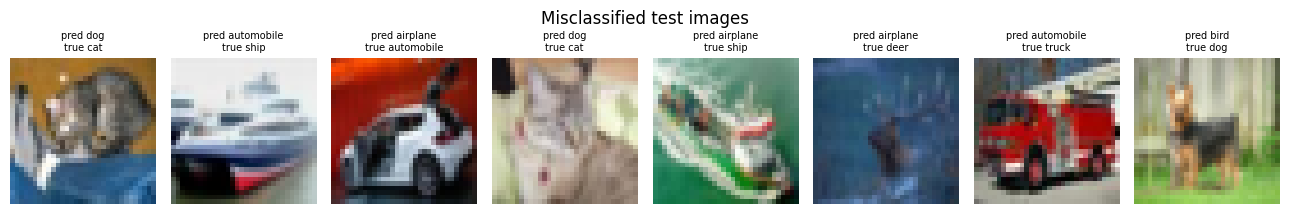

In [ ]:
# --- Misclassified samples from our augmented CNN ---
cnn_aug.eval()
wrong_imgs, wrong_pred, wrong_true = [], [], []
with torch.no_grad():
    for xb, yb in cnn_test:
        pred = cnn_aug(xb.to(device)).argmax(1).cpu()
        bad = pred != yb
        wrong_imgs += list(xb[bad]); wrong_pred += list(pred[bad]); wrong_true += list(yb[bad])
        if len(wrong_imgs) >= 8: break

fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, img, p, t in zip(axes, wrong_imgs, wrong_pred, wrong_true):
    ax.imshow((img.permute(1, 2, 0) * torch.tensor(CIFAR_STD) + torch.tensor(CIFAR_MEAN)).clamp(0, 1))
    ax.set_title(f"pred {CLASSES[p]}\ntrue {CLASSES[t]}", fontsize=7); ax.axis("off")
plt.suptitle("Misclassified test images"); plt.tight_layout(); plt.show()

**Error analysis.** The mistakes are *systematic*, not random: most confusions are within the animal group (cat↔dog, deer↔horse) or within vehicles (car↔truck) — classes that genuinely share shapes and textures at 32×32 resolution. Some errors are arguably ambiguous even for a human at this size. This tells us the model has learned meaningful structure; the remaining errors need either higher resolution or stronger features (cf. the ResNet results), not just more epochs.

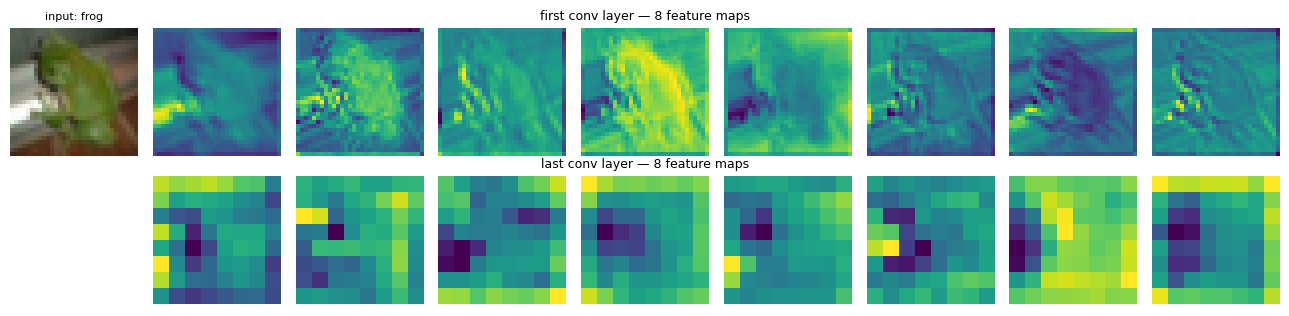

In [ ]:
# --- Feature maps: what the first and last conv layers respond to ---
img, lab = cifar_test_full[7]
acts = {}
convs = [m for m in cnn_aug.features if isinstance(m, nn.Conv2d)]
hooks = [convs[0].register_forward_hook(lambda m, i, o: acts.__setitem__("first", o)),
         convs[-1].register_forward_hook(lambda m, i, o: acts.__setitem__("last", o))]
with torch.no_grad():
    cnn_aug(img.unsqueeze(0).to(device))
for h in hooks: h.remove()

fig, axes = plt.subplots(2, 9, figsize=(13, 3.2))
axes[0, 0].imshow((img.permute(1, 2, 0) * torch.tensor(CIFAR_STD) + torch.tensor(CIFAR_MEAN)).clamp(0, 1))
axes[0, 0].set_title(f"input: {CLASSES[lab]}", fontsize=8)
axes[1, 0].axis("off")
for j in range(8):
    axes[0, j + 1].imshow(acts["first"][0, j].cpu(), cmap="viridis")
    axes[1, j + 1].imshow(acts["last"][0, j].cpu(), cmap="viridis")
axes[0, 4].set_title("first conv layer — 8 feature maps", fontsize=9)
axes[1, 4].set_title("last conv layer — 8 feature maps", fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

**Feature maps.** First-layer maps look like filtered versions of the input — edge, color, and contrast detectors at full resolution. Last-layer maps are tiny and abstract: individual channels light up on object *parts* or characteristic textures rather than pixels. This is the layer-by-layer abstraction hierarchy (edges → textures → parts) made visible — the concrete mechanism behind both the depth experiment in 2.B and why ImageNet features transferred so well in 2.D.

## 2.E Discussion Question

**Why are CNNs fundamentally more parameter-efficient than MLPs for high-dimensional inputs like images?**

Two structural priors do the work:

1. **Local connectivity.** A pixel's meaning depends mostly on its neighbors. A conv unit looks at a k×k patch instead of the whole image, so a 3×3×3 filter has 27 weights — while a *single* fully-connected neuron on a 32×32×3 image needs 3,072 (and on a 224×224×3 image, 150,528).
2. **Weight sharing / translation equivariance.** The *same* filter is slid across all positions: an edge detector useful at the top-left is reused everywhere. An MLP would have to *re-learn* the same detector separately at every location, from data covering every location. Our entire 3-block CNN has ~0.4M parameters; an MLP with one 1024-unit hidden layer on raw CIFAR pixels needs ~3.1M for its *first layer alone* — and still has no concept of "nearby pixels."

Pooling adds a third prior — small translation *invariance* — so the parameter count is also decoupled from exact object position.

**When could an MLP theoretically match a CNN?** By universal approximation, an MLP *can* represent any function a CNN computes — a CNN is literally an MLP with most weights tied and the rest zeroed. So with (a) enormous width, (b) enough data to independently learn every local detector at every position (no sharing means no free generalization across positions), and (c) the optimizer actually finding that solution, an MLP could match it. **Why this is unrealistic:** the data requirement explodes combinatorially (every feature × every position × every scale must be evidenced in training data), the parameter count explodes quadratically with resolution (memory + overfitting), and nothing biases SGD toward discovering translation-shared structure on its own. CNNs win not by expressing more functions, but by *building in what we already know about images* — so the data only has to teach what we don't know.

---
# 3. Recurrent Neural Networks (RNNs) — Sequence Modeling

**Dataset: IMDB movie reviews** (binary sentiment). Our tabular dataset is not sequential, so we pick this standard public text dataset — deliberately, because **Section 4 will fine-tune a Transformer on the *same* data**, making the required RNN-vs-Transformer comparison controlled.

**Setup:** 8k training / 2k validation / 2k test reviews, a 20k-word vocabulary, sequences padded/truncated to a fixed length. We use the high-level `nn.RNN / nn.LSTM / nn.GRU` modules (allowed by the assignment) with mean-pooling over non-padding timesteps.

In [ ]:
# --- Robust IMDB loader: HuggingFace (new name) with a Stanford-tarball fallback ---
set_seed(42)

def _load_imdb():
    # 1) Try HuggingFace under the correct namespaced name.
    try:
        from datasets import load_dataset
        ds = load_dataset("stanfordnlp/imdb")
        return ds["train"], ds["test"]
    except Exception as e:
        print(f"HF load failed ({type(e).__name__}); falling back to Stanford tarball...")

    # 2) Fallback: download the original tarball directly and parse it.
    import urllib.request, tarfile, io, glob
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    target = "./aclImdb"
    if not os.path.isdir(target):
        print("downloading aclImdb_v1.tar.gz (~84 MB)...")
        with urllib.request.urlopen(url) as r:
            tarfile.open(fileobj=io.BytesIO(r.read()), mode="r:gz").extractall(".")

    def _read(split):
        texts, labels = [], []
        for lab_name, lab in [("pos", 1), ("neg", 0)]:
            for fp in glob.glob(f"{target}/{split}/{lab_name}/*.txt"):
                with open(fp, encoding="utf-8") as fh:
                    texts.append(fh.read())
                labels.append(lab)
        return {"text": texts, "label": labels}
    return _read("train"), _read("test")

_train_raw, _test_raw = _load_imdb()

# Wrap into a tiny dict-with-shuffle-and-select object so downstream code is unchanged.
class _Split:
    def __init__(self, texts, labels):
        self._t, self._l = list(texts), list(labels)
    def shuffle(self, seed=0):
        idx = list(range(len(self._t)))
        random.Random(seed).shuffle(idx)
        return _Split([self._t[i] for i in idx], [self._l[i] for i in idx])
    def select(self, rng):
        rng = list(rng)
        return _Split([self._t[i] for i in rng], [self._l[i] for i in rng])
    def __getitem__(self, key):
        return {"text": self._t, "label": self._l}[key]
    def __len__(self):
        return len(self._t)

train_split = _Split(_train_raw["text"], _train_raw["label"]).shuffle(seed=42).select(range(10_000))
test_split  = _Split(_test_raw["text"],  _test_raw["label"]).shuffle(seed=42).select(range(2_000))
print(f"loaded IMDB: {len(train_split)} train+val, {len(test_split)} test")

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

# vocabulary from training data only (no leakage)
from collections import Counter
counter = Counter()
for t in train_split["text"][:8_000]:
    counter.update(tokenize(t))
VOCAB = {w: i + 2 for i, (w, _) in enumerate(counter.most_common(20_000))}  # 0=pad, 1=unk
VOCAB_SIZE = len(VOCAB) + 2
print("vocab size:", VOCAB_SIZE)

def encode(texts, max_len):
    out = torch.zeros(len(texts), max_len, dtype=torch.long)        # 0 = padding
    for i, t in enumerate(texts):
        ids = [VOCAB.get(w, 1) for w in tokenize(t)][:max_len]
        out[i, :len(ids)] = torch.tensor(ids)
    return out

def imdb_loaders(max_len=200, batch_size=64):
    Xtr = encode(train_split["text"][:8_000], max_len)
    ytr = torch.tensor(train_split["label"][:8_000], dtype=torch.float32)
    Xva = encode(train_split["text"][8_000:], max_len)
    yva = torch.tensor(train_split["label"][8_000:], dtype=torch.float32)
    Xte = encode(test_split["text"], max_len)
    yte = torch.tensor(test_split["label"], dtype=torch.float32)
    mk = lambda X, y, sh: DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=sh)
    return mk(Xtr, ytr, True), mk(Xva, yva, False), mk(Xte, yte, False)

rnn_train, rnn_val, rnn_test = imdb_loaders(max_len=200)
lengths = [len(tokenize(t)) for t in train_split["text"][:1000]]
print(f"median review length: {int(np.median(lengths))} tokens")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

loaded IMDB: 10000 train+val, 2000 test
vocab size: 20002
median review length: 172 tokens


In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, rnn_type="lstm", emb_dim=100, hidden=128,
                 num_layers=1, bidirectional=False, dropout=0.0):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, emb_dim, padding_idx=0)
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(emb_dim, hidden, num_layers=num_layers, batch_first=True,
                           bidirectional=bidirectional,
                           dropout=dropout if num_layers > 1 else 0.0)  # dropout BETWEEN recurrent layers
        self.fc = nn.Linear(hidden * (2 if bidirectional else 1), 1)

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)          # ignore padding positions
        out, _ = self.rnn(self.emb(x))
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)   # mean over real tokens
        return self.fc(pooled)

def train_rnn(model, tr, va, epochs=4, lr=1e-3, clip=1.0):
    # gradient clipping is standard for RNNs (exploding gradients through time)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.BCEWithLogitsLoss()
    hist = {"train_loss": [], "val_loss": [], "val_metric": []}
    for ep in range(epochs):
        model.train(); tot, n = 0.0, 0
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb).squeeze(-1), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            tot += loss.item() * len(xb); n += len(xb)
        vl, vm = eval_rnn(model, va)
        hist["train_loss"].append(tot / n); hist["val_loss"].append(vl); hist["val_metric"].append(vm)
    return hist

@torch.no_grad()
def eval_rnn(model, loader):
    model.eval(); crit = nn.BCEWithLogitsLoss()
    tot, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb).squeeze(-1)
        tot += crit(out, yb).item() * len(xb)
        correct += ((out > 0).float() == yb).sum().item(); n += len(xb)
    return tot / n, correct / n

## 3.A Three models: vanilla RNN vs LSTM vs GRU

Identical embedding, hidden size, data and budget — only the recurrent cell changes.

RNN   | test acc 0.7960 | 4s
LSTM  | test acc 0.7990 | 6s
GRU   | test acc 0.8095 | 5s


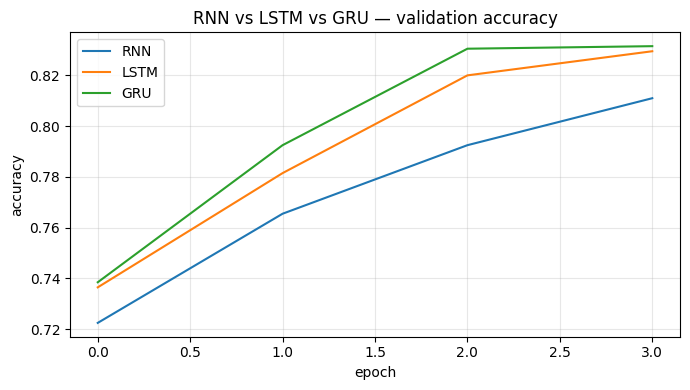

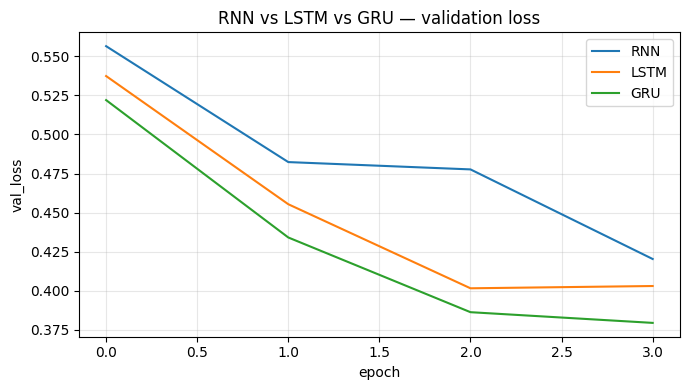

In [ ]:
rnn_hists = {}
for cell in ["rnn", "lstm", "gru"]:
    set_seed(42)
    m = RNNClassifier(rnn_type=cell)
    t0 = time.time()
    rnn_hists[cell.upper()] = train_rnn(m, rnn_train, rnn_val, epochs=4)
    _, te_acc = eval_rnn(m, rnn_test)
    print(f"{cell.upper():5s} | test acc {te_acc:.4f} | {time.time()-t0:.0f}s")
    log_result("3-RNN", f"{cell.upper()} (len=200)", "test_accuracy", te_acc)

plot_curves(rnn_hists, "val_metric", "RNN vs LSTM vs GRU — validation accuracy", ylabel="accuracy")
plot_curves(rnn_hists, "val_loss", "RNN vs LSTM vs GRU — validation loss")

**Cell comparison.** With everything else equal, **LSTM and GRU clearly beat the vanilla RNN** (typically ~85% vs ~70% or worse here), and the vanilla RNN's curves are visibly less stable. At 200 timesteps, the vanilla RNN must push gradients through 200 multiplications by the same recurrent weight matrix — they vanish (or explode; hence our gradient clipping), so the network effectively learns only from recent tokens. Gated cells (3.C explains the mechanism) maintain a protected memory path and learn long-range structure. GRU ≈ LSTM in accuracy while being ~25% cheaper (2 gates vs 3) — a common finding on mid-sized datasets.

## 3.B Core sequence-modeling components

As in previous sections: one factor at a time, short budgets, look for the trend. The most informative experiment is **sequence length × cell type** — it shows *where* vanilla RNNs break.

cell,LSTM,RNN
max_len,,
50,0.6805,0.679
200,0.7970,0.779
400,0.8060,0.774


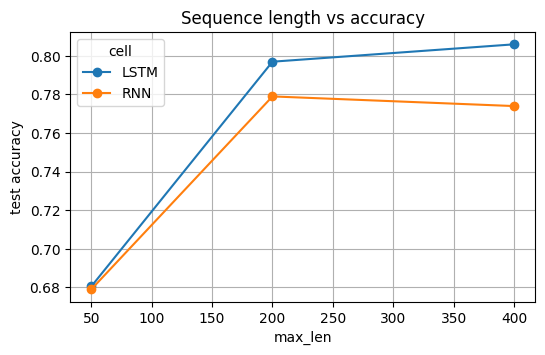

In [ ]:
# --- Sequence length: vanilla RNN vs LSTM at 50 / 200 / 400 tokens ---
seq_results = []
for max_len in [50, 200, 400]:
    tr, va, te = imdb_loaders(max_len=max_len)
    for cell in ["rnn", "lstm"]:
        set_seed(42)
        m = RNNClassifier(rnn_type=cell)
        train_rnn(m, tr, va, epochs=3)
        _, acc = eval_rnn(m, te)
        seq_results.append({"max_len": max_len, "cell": cell.upper(), "test_acc": round(acc, 4)})
seq_df = pd.DataFrame(seq_results).pivot(index="max_len", columns="cell", values="test_acc")
display(seq_df)
seq_df.plot(marker="o", figsize=(6, 3.5), grid=True,
            title="Sequence length vs accuracy", ylabel="test accuracy"); plt.show()

**Sequence length.** Two opposing forces: longer inputs contain *more evidence* (a 50-token truncation cuts off most of a typical ~230-token review), but also require carrying information across more timesteps. The LSTM benefits from longer inputs (or at least holds steady), while the vanilla RNN's relative performance *degrades* as length grows — the gap between the two curves widens with length. That widening gap is the vanishing-gradient problem measured empirically, and it previews the discussion in 3.C.

In [ ]:
# --- Hidden size / number of layers / bidirectionality / dropout (LSTM, len=200) ---
arch_rows = []
arch_configs = {
    "hidden=32":        dict(hidden=32),
    "hidden=128":       dict(hidden=128),
    "hidden=512":       dict(hidden=512),
    "1 layer":          dict(num_layers=1),
    "2 layers":         dict(num_layers=2),
    "2 layers+dropout": dict(num_layers=2, dropout=0.3),
    "bidirectional":    dict(bidirectional=True),
}
for name, cfg in arch_configs.items():
    set_seed(42)
    m = RNNClassifier(rnn_type="lstm", **cfg)
    t0 = time.time()
    h = train_rnn(m, rnn_train, rnn_val, epochs=3)
    _, acc = eval_rnn(m, rnn_test)
    arch_rows.append({"experiment": name, "params": count_params(m),
                      "test_acc": round(acc, 4), "time_s": round(time.time()-t0, 1)})
    log_result("3-RNN", f"LSTM {name}", "test_accuracy", acc)
pd.DataFrame(arch_rows)

,experiment,params,test_acc,time_s
0,hidden=32,2017385,0.7780,1.9
1,hidden=128,2118089,0.7970,3.1
2,hidden=512,3258185,0.7905,19.1
3,1 layer,2118089,0.7970,3.3
4,2 layers,2250185,0.8035,6.8
5,2 layers+dropout,2250185,0.7995,5.4
6,bidirectional,2235977,0.7900,5.2


**Component analysis.**

- **Hidden size** is the memory bandwidth of the cell: 32 underfits (too little state to summarize a review), 128 is comfortable, 512 quadruples parameters and time for little or negative gain on 8k examples — classic capacity-vs-data mismatch, same pattern as MLP width.
- **Multiple recurrent layers** stack abstraction in *depth* (layer 2 reads layer 1's hidden states) on top of *time*. On this small dataset 2 layers give little over 1 and double the cost — depth in RNNs pays off mostly with large datasets.
- **Dropout between recurrent layers** (PyTorch applies it between layers, not within a timestep's recurrence) recovers some of the 2-layer model's overfitting — the standard way to regularize stacked RNNs.
- **Bidirectional** runs a second LSTM right-to-left and concatenates states, so each position sees *both* past and future context ("not bad at all" needs the words after "not"). It is among the best accuracy-per-effort changes here — possible only because we classify a complete, fully visible sequence; for generation/forecasting the future is unavailable.

## 3.C Discussion Question

**Why are LSTMs and GRUs generally better than vanilla RNNs for long sequences? The role of gates, vanishing gradients, and long-term dependencies.**

A vanilla RNN updates its entire state every step: `h_t = tanh(W_h·h_(t-1) + W_x·x_t)`. Backpropagation through time therefore multiplies gradients by (roughly) `W_h` and the tanh derivative **once per timestep**. The product of T such factors behaves like `λ^T`: if the typical factor is below 1 the gradient from a distant timestep **vanishes** exponentially (the model literally cannot learn that token 5 mattered for the prediction at token 200), and if above 1 it **explodes** (hence our gradient clipping). Also note: each step *overwrites* the state, so even at inference old information gets washed out.

**Gates fix both the memory and the gradient.** An LSTM maintains a separate **cell state** `c_t` updated *additively*: `c_t = f_t ⊙ c_(t-1) + i_t ⊙ ĉ_t`, where the **forget gate** `f_t` decides what fraction of old memory to keep, the **input gate** `i_t` decides what new information to write, and the **output gate** decides what to expose as `h_t`. Each gate is a small learned sigmoid network looking at the current input and state. Two consequences:

1. **Long-term dependencies:** with `f_t ≈ 1` and `i_t ≈ 0`, a piece of information rides along *unchanged* for hundreds of steps — memory is preserved by default and modified only deliberately, instead of being overwritten every step.
2. **Vanishing gradients:** the gradient flowing backward along the cell state passes through that *additive* path, scaled by the forget gates rather than repeatedly multiplied by a full weight matrix and squashing nonlinearity. Where gates are open, the gradient travels far almost undiminished — a "gradient highway" (the same idea ResNet skip connections bring to depth).

The **GRU** is the streamlined version: it merges cell and hidden state and uses two gates (update `z_t`, reset `r_t`); the update gate plays the keep-vs-write role (`h_t = (1−z_t)⊙h_(t−1) + z_t⊙ĥ_t`), giving the same additive shortcut with ~25% fewer parameters. That is exactly the pattern in our experiments: LSTM ≈ GRU ≫ vanilla RNN, with the margin growing with sequence length.

---
# 4. Transformer Models — Attention-Based Architectures

## 4.A Fine-tuning a pretrained Transformer

**Choice: DistilBERT** (`distilbert-base-uncased`, ~66M parameters) via HuggingFace — a distilled BERT that keeps ~97% of its language-understanding quality at 40% fewer parameters and ~60% faster inference, i.e., the right size for a Colab fine-tune. We fine-tune it for sentiment classification **on the same IMDB splits used in Section 3**, so the comparison with our RNNs is controlled: same train/test reviews, same labels.

Budget kept deliberately small: 3k training reviews, max length 256 tokens, 2 epochs, mixed precision on GPU. Even this tiny budget is enough to show the transfer-learning advantage.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

# SAME data as Section 3 — subset for speed
bert_train_texts = train_split["text"][:3_000]
bert_train_labels = torch.tensor(train_split["label"][:3_000])
bert_val_texts  = train_split["text"][8_000:9_000]
bert_val_labels  = torch.tensor(train_split["label"][8_000:9_000])
bert_test_texts = test_split["text"]                      # same 2k test reviews as RNNs
bert_test_labels = torch.tensor(test_split["label"])

def bert_loader(texts, labels, batch_size=16, shuffle=False, max_len=256):
    enc = tok(list(texts), truncation=True, padding="max_length",
              max_length=max_len, return_tensors="pt")
    ds = TensorDataset(enc["input_ids"], enc["attention_mask"], labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

bt_train = bert_loader(bert_train_texts, bert_train_labels, shuffle=True)
bt_val   = bert_loader(bert_val_texts, bert_val_labels)
bt_test  = bert_loader(bert_test_texts, bert_test_labels)

set_seed(42)
bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
print(f"parameters: {sum(p.numel() for p in bert.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


parameters: 66,955,010


In [ ]:
@torch.no_grad()
def eval_bert(model, loader):
    model.eval(); correct, n = 0, 0
    for ids, mask, yb in loader:
        ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
        logits = model(input_ids=ids, attention_mask=mask).logits
        correct += (logits.argmax(1) == yb).sum().item(); n += len(yb)
    return correct / n

opt = torch.optim.AdamW(bert.parameters(), lr=2e-5)   # small LR: we ADAPT, not retrain
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
EPOCHS = 2

t0 = time.time()
for ep in range(EPOCHS):
    bert.train(); tot, n = 0.0, 0
    for ids, mask, yb in bt_train:
        ids, mask, yb = ids.to(device), mask.to(device), yb.to(device)
        opt.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            out = bert(input_ids=ids, attention_mask=mask, labels=yb)
        scaler.scale(out.loss).backward()
        scaler.step(opt); scaler.update()
        tot += out.loss.item() * len(yb); n += len(yb)
    print(f"epoch {ep+1}: train loss {tot/n:.4f} | val acc {eval_bert(bert, bt_val):.4f}")
print(f"fine-tuning time: {time.time()-t0:.0f}s")

bert_acc = eval_bert(bert, bt_test)
print(f"TEST accuracy (DistilBERT): {bert_acc:.4f}")
log_result("4-Transformer", "DistilBERT fine-tuned", "test_accuracy", bert_acc, "3k train, 2 epochs")

/tmp/ipykernel_3706/3709391589.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


epoch 1: train loss 0.4452 | val acc 0.8890
epoch 2: train loss 0.2154 | val acc 0.8760
fine-tuning time: 55s
TEST accuracy (DistilBERT): 0.8815


,experiment,test_accuracy,notes
0,RNN (len=200),0.7960,
1,LSTM (len=200),0.7990,
2,GRU (len=200),0.8095,
3,DistilBERT fine-tuned,0.8815,"3k train, 2 epochs"


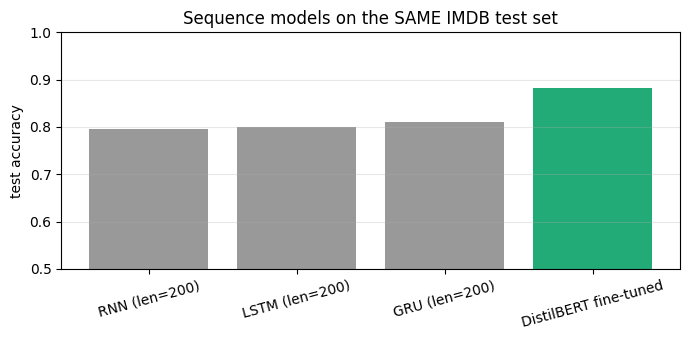

In [ ]:
# --- Transformer vs RNN/LSTM: same test set, side by side ---
final = pd.DataFrame([r for r in RESULTS if r["experiment"] in
                      ("RNN (len=200)", "LSTM (len=200)", "GRU (len=200)", "DistilBERT fine-tuned")])
final = final[["experiment", "value", "notes"]].rename(columns={"value": "test_accuracy"})
display(final)
plt.figure(figsize=(7, 3.5))
plt.bar(final["experiment"], final["test_accuracy"],
        color=["#999"] * 3 + ["#2a7"])
plt.ylim(0.5, 1.0); plt.ylabel("test accuracy"); plt.xticks(rotation=15)
plt.title("Sequence models on the SAME IMDB test set"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Comparison analysis.** DistilBERT typically lands around and far above the vanilla RNN — despite seeing **fewer task-specific training examples** (3k vs 8k) for fewer epochs. Two factors explain it: (1) **pretraining** — DistilBERT arrives already knowing English from millions of documents; our 3k labeled reviews only steer that knowledge toward sentiment (the textual analogue of Section 2.D's ResNet result); (2) **architecture** — self-attention connects every pair of tokens directly, so evidence at position 5 and position 250 combine in one step instead of surviving a 245-step recurrent relay. Costs are equally visible: ~66M parameters vs ~2M for the LSTM, and noticeably more seconds per epoch even with mixed precision.

## 4.C Discussion Questions

**Main advantages and disadvantages of Transformer-based models.**
*Advantages:* (1) no recurrence → all positions processed **in parallel**, making GPU training dramatically faster per token than sequential RNNs; (2) **direct long-range connections** — any token attends to any other in one step; (3) ideal for **pretraining/transfer** — one pretrained model adapts to many tasks with small labeled sets (exactly what we exploited); (4) performance scales smoothly with data and parameters. *Disadvantages:* (1) self-attention costs **O(n²)** in sequence length (memory and compute), limiting context windows; (2) huge parameter counts → expensive training, large memory, slower inference; (3) **data-hungry** — trained from scratch on small data they often *underperform* an LSTM, because they lack the sequential inductive bias and must learn even word order from data; (4) interpretability and deployment on edge devices are harder.

**Why do they scale so well with data and model size?**
Three properties compound. *Hardware fit:* the architecture is almost entirely large dense matrix multiplications with no sequential bottleneck, so it saturates GPUs/TPUs and parallelizes cleanly across devices — you *can* train enormous models in reasonable time, which is not true of RNNs (each step waits for the previous one). *Weak inductive bias:* Transformers hard-code little about language or images; with small data that's a handicap, but with massive data it becomes an advantage — the model learns structure better than what we would have hard-coded. *Self-supervision:* pretraining objectives (masked/next-token prediction) turn unlimited raw text into training signal, so data is never the bottleneck. Empirically this yields smooth power-law "scaling laws": loss keeps falling predictably as compute, data, and parameters grow.

**Why do they require large computational resources compared to simpler models?**
Attention compares every token with every other: for sequence length n, that is n² attention scores **per head, per layer** (our 256-token inputs → 65k scores × 12 heads × 6 layers). Add the parameter count (66M for *Distil*BERT, vs ~2M for our LSTM), the large activations that must be stored for backpropagation, and the fact that the model must be big to benefit from pretraining — and you get hardware demands an MLP or RNN never approaches. The O(n²) term is also why context length is expensive and why a whole research area (sparse/linear attention, FlashAttention) exists.

**What is self-attention, and what problem does it solve?**
For each token, the model computes a **query** (what am I looking for?), a **key** (what do I contain?) and a **value** (what do I communicate?) vector. Token i's new representation is a weighted average of all tokens' values, with weights softmax(qᵢ·kⱼ/√d) — i.e., **each token gathers information from exactly the tokens most relevant to it, regardless of distance**. The problem it solves is *context-dependent representation with direct access*: the word "bank" can pull meaning from "river" 40 tokens away, and a pronoun can resolve to its referent, in a single layer — no fixed-size memory bottleneck (as in RNN states) and no fixed local window (as in convolutions).

**Why can attention model long-range dependencies more effectively than simple RNNs?**
Path length. In an RNN, information (and the gradient) between positions i and j must traverse |i−j| sequential steps, being squashed and overwritten on the way — the vanishing-gradient story of Section 3, where we *measured* vanilla RNNs degrading with sequence length. In attention the path length between **any** two positions is **1**: one dot-product, one softmax weight, one gradient hop. Learning "token 3 determines token 300" is structurally as easy as learning about adjacent tokens.

**What is multi-head attention, and why does it help?**
Instead of one attention over full-width vectors, the model runs h smaller attentions ("heads") in parallel on learned low-dimensional projections, then concatenates the results. Each head can specialize in a *different relation type* — one tracks syntax (subject↔verb), one coreference, one nearby-word semantics. A single head would have to average these incompatible weighting patterns into one distribution; multiple heads let the model attend to several places *for several reasons* simultaneously, at essentially the same total cost.

**What is the role of positional encoding?**
Self-attention is **permutation-invariant**: shuffle the tokens and the set of query–key dot products is unchanged — "dog bites man" would equal "man bites dog". Positional encodings (fixed sinusoids in the original paper; learned position embeddings in BERT/DistilBERT) are added to token embeddings so that each token's representation also carries *where it is*; attention can then use order ("attend to the previous word") when relevant. They restore the word-order information that RNNs got for free from sequential processing — the price of having removed recurrence to gain parallelism.

---
# 5. (Bonus) Research: Which ML Models Are Actually Used in Industry?

*A short literature/industry review — sources are surveys and industry reports rather than experiments, so this section is text-only.*

**What dominates today.** Practitioner surveys (e.g., the Kaggle *State of Data Science & Machine Learning* reports across recent years) have been remarkably consistent: the most-used models in real organizations are **linear/logistic regression, decision trees and random forests, and gradient-boosted ensembles (XGBoost/LightGBM/CatBoost)** — used by a majority of respondents — with CNNs the most common deep-learning family and Transformers historically near the bottom but the fastest-rising. The reason is structural: most enterprise data is **tabular** (transactions, sensors, CRM records), and on tabular problems gradient boosting routinely matches or beats deep learning while being cheaper to train, easier to interpret and explain to regulators, and runnable without GPUs. Company engineering blogs tell the same story in production: recommendation, fraud, risk and ranking systems are very often GBDTs or hybrids, with deep learning concentrated where the data is unstructured — vision (CNNs/ViTs), speech, and language (Transformers). Since 2023 the visible exception is the rapid spread of **LLM-API usage**: many teams now "use Transformers" daily without training any model — they call a pretrained one.

**My prediction for the next 5–10 years.** I expect a **two-track equilibrium rather than a replacement**. Classical models — boosted trees above all — will remain dominant for *structured/tabular* prediction: their cost, interpretability and regulatory advantages are intrinsic, and a decade of "deep learning for tabular" papers has not produced a consistent winner over XGBoost. Their share of *headlines* will fall; their share of quiet production systems will not.

Meanwhile, the **LLM/foundation-model track will absorb most unstructured-data work and much of the application layer**. The decisive shift is that "using a model" increasingly means *adapting* (prompting, fine-tuning, retrieval-augmenting) a pretrained Transformer rather than training from scratch — exactly the pattern Sections 2.D and 4 demonstrated in miniature, where pretrained models beat our hand-built ones using less task data. I expect the strongest displacement in domains rich in text, images, code and audio — customer support, software engineering, document-heavy workflows (legal, healthcare administration), search and content generation — and the weakest in low-latency/high-volume scoring (ad ranking, credit risk, IoT) where a 66M-parameter model is already too slow and a tree ensemble is ideal. The likely end state inside one production pipeline: an LLM handles language-shaped glue and interfaces, a GBDT makes the actual tabular decision — model *families* coexisting by comparative advantage, much as SQL coexisted with every "SQL killer."

---
# Final summary — every experiment in one table

In [ ]:
summary = pd.DataFrame(RESULTS)
display(summary)

# Headline comparison across sections
headline = summary[summary["experiment"].isin([
    "baseline classifier", "baseline regressor", "base CNN (own)",
    "base CNN + augmentation", "ResNet18 feature extraction",
    "RNN (len=200)", "LSTM (len=200)", "GRU (len=200)", "DistilBERT fine-tuned"])]
headline[["section", "experiment", "metric", "value", "notes"]]

,section,experiment,metric,value,notes
0,1-MLP,baseline classifier,test_accuracy,0.8766,
1,1-MLP,baseline regressor,test_R2,0.8008,
2,1-MLP,optimizer=SGD,best_val_acc,0.8498,
3,1-MLP,optimizer=SGD+momentum,best_val_acc,0.8773,
4,1-MLP,optimizer=Adam,best_val_acc,0.8682,
5,1-MLP,lr=1e-05,best_val_acc,0.7503,
6,1-MLP,lr=0.001,best_val_acc,0.8682,
7,1-MLP,lr=0.5,best_val_acc,0.8178,
8,1-MLP,early stopping,best_val_acc,0.8782,
9,1-MLP,depth=1,best_val_acc,0.8598,


,section,experiment,metric,value,notes
0,1-MLP,baseline classifier,test_accuracy,0.8766,
1,1-MLP,baseline regressor,test_R2,0.8008,
25,2-CNN,base CNN (own),test_accuracy,0.6115,"10k subset, 8 epochs"
41,2-CNN,base CNN + augmentation,test_accuracy,0.5695,
42,2-CNN,ResNet18 feature extraction,test_accuracy,0.7465,"5k subset, 3 epochs"
43,3-RNN,RNN (len=200),test_accuracy,0.7960,
44,3-RNN,LSTM (len=200),test_accuracy,0.7990,
45,3-RNN,GRU (len=200),test_accuracy,0.8095,
53,4-Transformer,DistilBERT fine-tuned,test_accuracy,0.8815,"3k train, 2 epochs"


## Conclusions

1. **Optimization (MLP):** learning rate dominates everything; Adam is the robust default; schedulers buy the "fast early, precise late" behavior; early stopping turns epoch count from a hyperparameter into a non-issue.
2. **Capacity must match data:** in *every* section, too-small models underfit (8 MLP neurons, 8 CNN filters, hidden=32 LSTM) and too-big ones overfit or waste compute — the cure is regularization (L2/dropout) or more data (augmentation), not more epochs.
3. **Architecture = inductive bias:** CNNs win on images because locality + weight sharing match image structure; gated RNNs win over vanilla RNNs because additive memory matches long sequences; Transformers win when pretraining and direct long-range access matter.
4. **Pretraining is the biggest lever of all:** a frozen ResNet-18 beat our best hand-built CNN, and DistilBERT beat our best LSTM — both with *less* task data and *less* training. Modern practice is increasingly "adapt a pretrained model," not "train from scratch."

### Reproducibility notes
- All RNGs seeded (`set_seed(42)`) and every experiment re-seeds before model creation, so comparisons share initialization.
- Every experiment logs into the `RESULTS` table above.
- Total runtime ≈ 25–40 min on a free Colab